# Task 2: Quantitative Analysis using TA-Lib

This notebook loads historical stock price data, computes technical indicators, and visualizes the results to understand market behavior. It supports Task 2 deliverables with clean data preparation and indicator analysis.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
import os
from pathlib import Path


import warnings
warnings.filterwarnings('ignore')


## 1. Historical Stock Data Load

Load daily stock price data from Yahoo Finance and inspect the price DataFrame.


In [33]:
stocks = ['AAPL', 'AMZN', 'META', 'GOOG', 'NVDA']

stock_data = {}

# Load CSV files
for stock in stocks:
    
    path = f'../data/raw/{stock}.csv'
    
    stock_data[stock] = pd.read_csv(path)

# Convert Date column
for stock in stock_data:
    
    stock_data[stock]['Date'] = pd.to_datetime(
        stock_data[stock]['Date']
    )

# Check data types
stock_data['GOOG'].info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [34]:
# Check data types for all stocks
for stock in stock_data:
    
    print(f"\n{stock} DATA TYPES")
    print("-" * 40)
    
    print(stock_data[stock].info())


AAPL DATA TYPES
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB
None

AMZN DATA TYPES
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4

In [35]:
# Check missing values for all stocks
for stock in stock_data:
    
    print(f"\n{stock} Missing Values")
    print(stock_data[stock].isnull().sum())


AAPL Missing Values
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

AMZN Missing Values
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

META Missing Values
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

GOOG Missing Values
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

NVDA Missing Values
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## 2. Plot Closing Prices

Plot Closing Prices

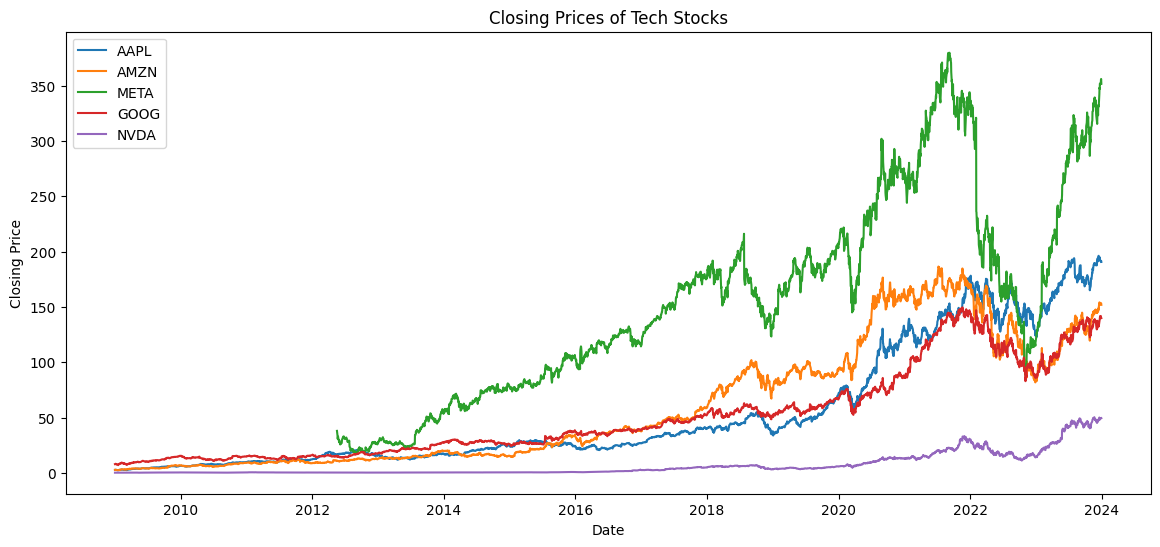

In [36]:
plt.figure(figsize=(14,6))

for stock in stock_data:
    
    plt.plot(
        stock_data[stock]['Date'],
        stock_data[stock]['Close'],
        label=stock
    )

plt.title("Closing Prices of Tech Stocks")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

## 3. Reusable Analysis Workflow

Define a function to perform technical analysis and visualization for a given stock.


In [37]:
def analyze_stock(df, symbol):
    """    
Parameters:
    df (pd.DataFrame): Stock data with columns like Date, Close, etc.
    symbol (str): Stock symbol for labeling plots.
    """
    # Compute Daily Returns
    if 'Daily_Return' not in df.columns:
        df['Daily_Return'] = df['Close'].pct_change() * 100
    
    # Compute Moving Averages
    if 'SMA_20' not in df.columns:
        df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
    if 'SMA_50' not in df.columns:
        df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)
    if 'EMA_20' not in df.columns:
        df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
    
    # Compute RSI
    if 'RSI' not in df.columns:
        df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
    
    # Compute MACD
    if 'MACD' not in df.columns or 'Signal' not in df.columns or 'Histogram' not in df.columns:
        macd, signal, hist = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
        df['MACD'] = macd
        df['Signal'] = signal
        df['Histogram'] = hist
    
        # -----------------------
        # Visualization Section
        # -----------------------
        
    # Plot Closing Price with SMA
    plt.figure(figsize=(14,6))
    plt.plot(df['Date'], df['Close'], label='Close')
    plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
    plt.plot(df['Date'], df['SMA_50'], label='SMA 50')
    plt.title(f"{symbol} Closing Price with SMA")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
    
    # Plot RSI
    plt.figure(figsize=(14,5))
    plt.plot(df['Date'], df['RSI'])
    plt.axhline(70, linestyle='--')
    plt.axhline(30, linestyle='--')
    plt.title(f"{symbol} RSI")
    plt.xlabel("Date")
    plt.ylabel("RSI")
    plt.show()
    
    # Plot MACD
    plt.figure(figsize=(14,6))
    plt.plot(df['Date'], df['MACD'], label='MACD')
    plt.plot(df['Date'], df['Signal'], label='Signal')
    plt.title(f"{symbol} MACD")
    plt.xlabel("Date")
    plt.ylabel("MACD")
    plt.legend()
    plt.show()
    
    # Plot Daily Return Distribution
    plt.figure(figsize=(12, 5))
    sns.histplot(df['Daily_Return'].dropna(), bins=40, kde=True, color='teal')
    plt.title(f"{symbol} Daily Return Distribution")
    plt.xlabel("Daily Return (%)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    
    # Plot Daily Returns Over Time
    plt.figure(figsize=(14, 5))
    plt.plot(df['Date'], df['Daily_Return'], color='brown', linewidth=0.8)
    plt.title(f"{symbol} Daily Returns Over Time")
    plt.xlabel("Date")
    plt.ylabel("Daily Return (%)")
    plt.tight_layout()
    plt.show()


## 4. Analysis for each Stock

Apply the analysis workflow to AAPL, AMZN, META, GOOG, NVDA.


--- Analyzing AAPL ---


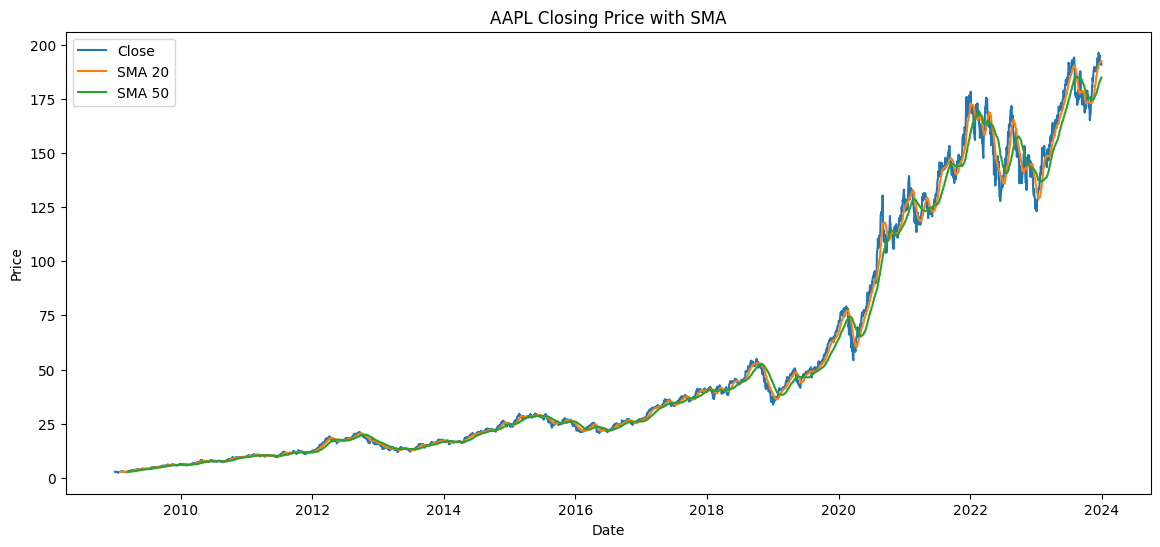

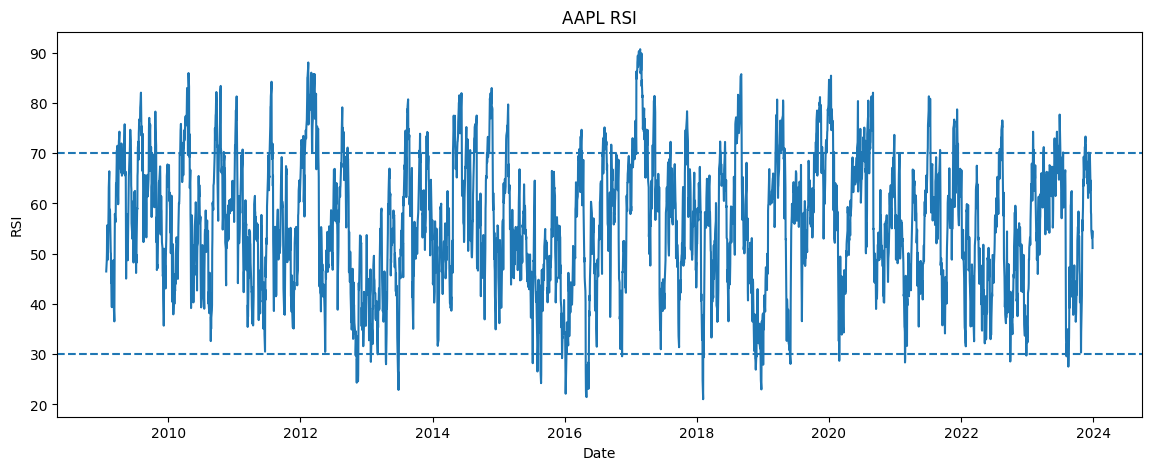

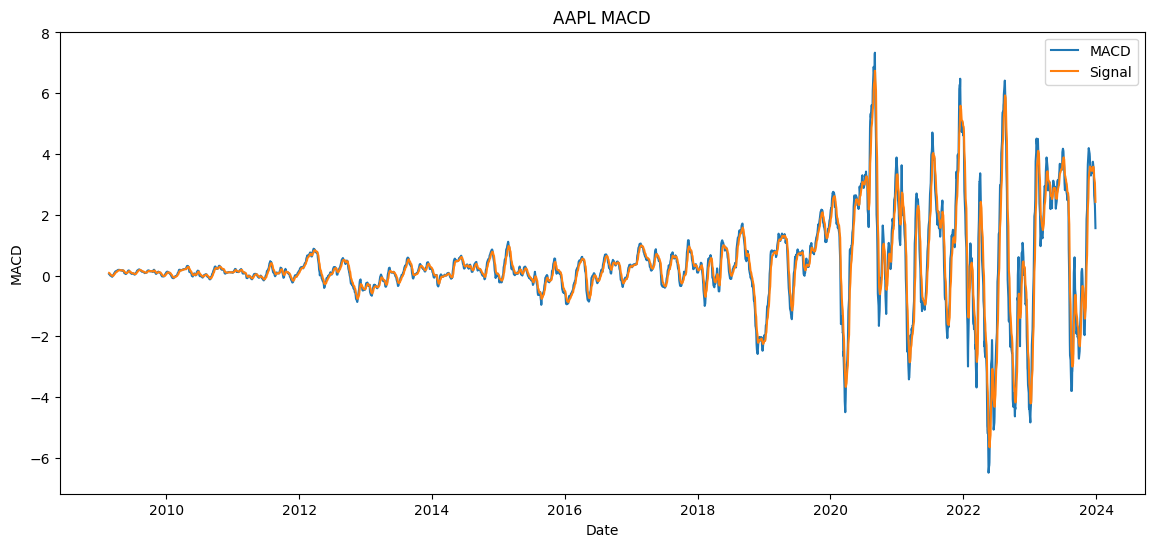

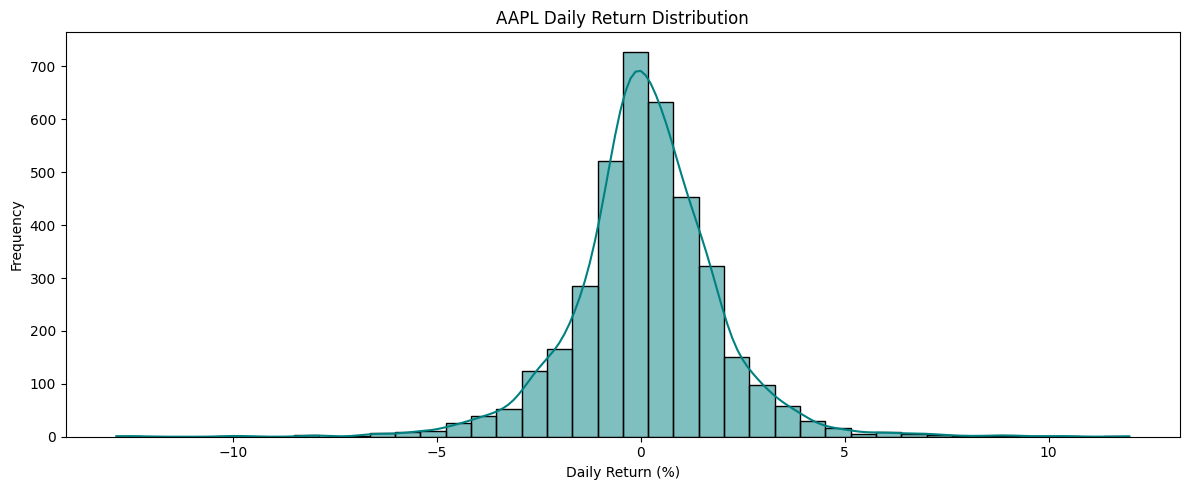

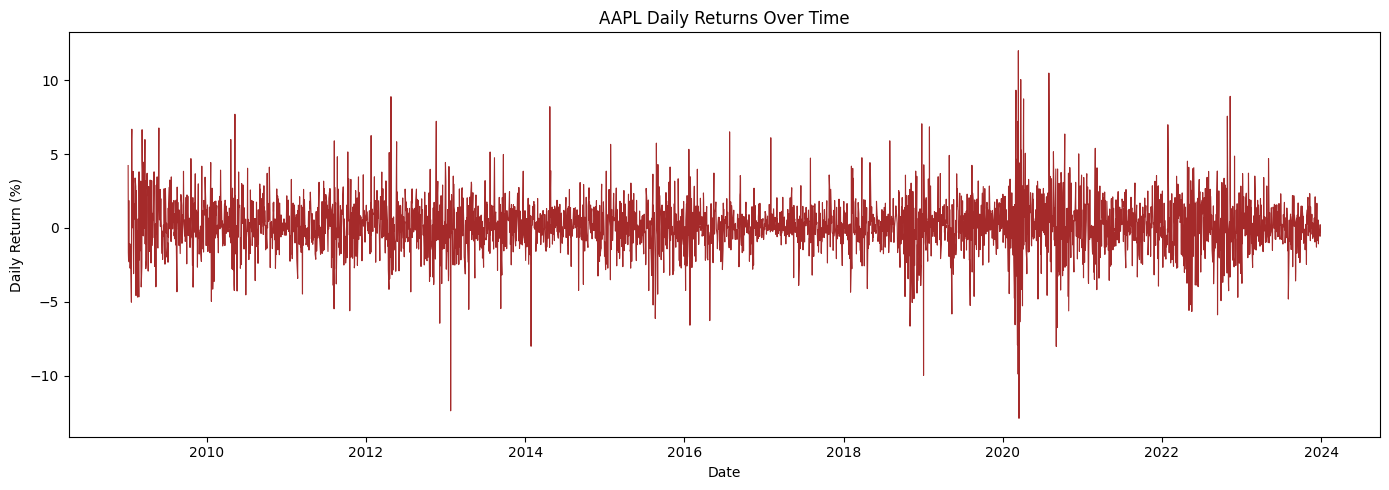

In [38]:
# Analyze AAPL explicitly
symbol = 'AAPL'
print(f"--- Analyzing {symbol} ---")
analyze_stock(stock_data[symbol], symbol)


--- Analyzing AMZN ---


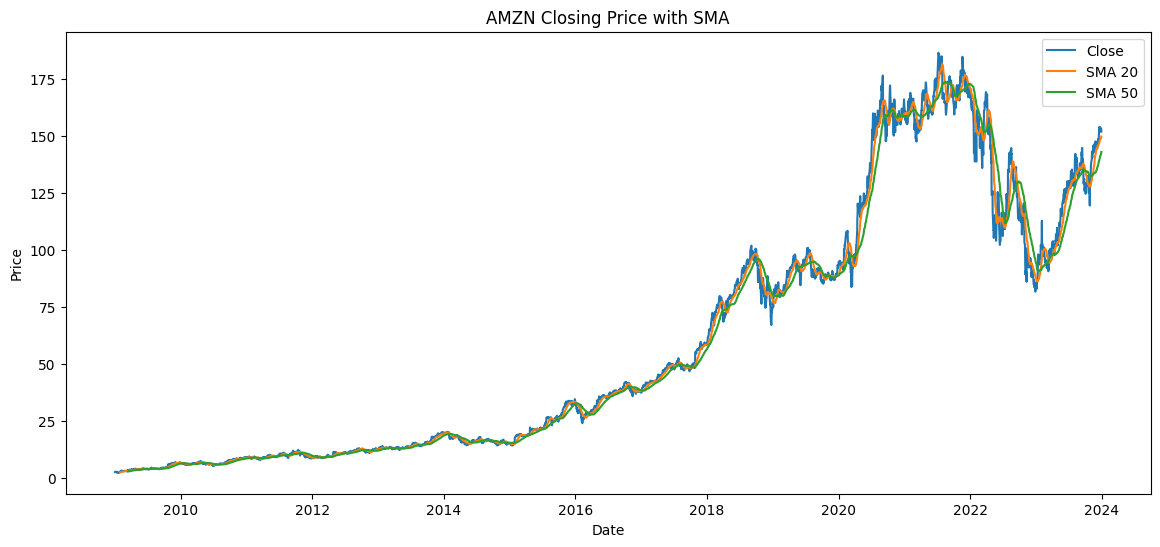

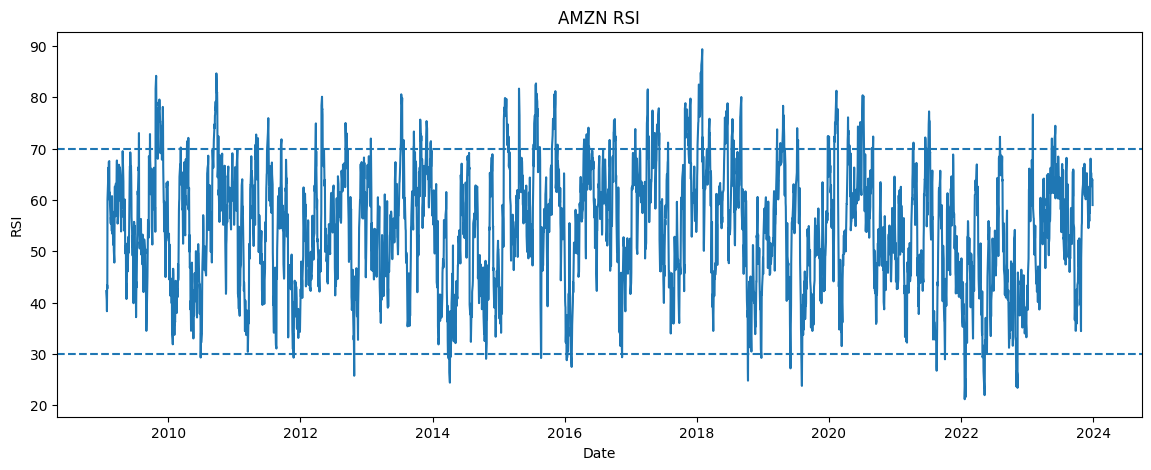

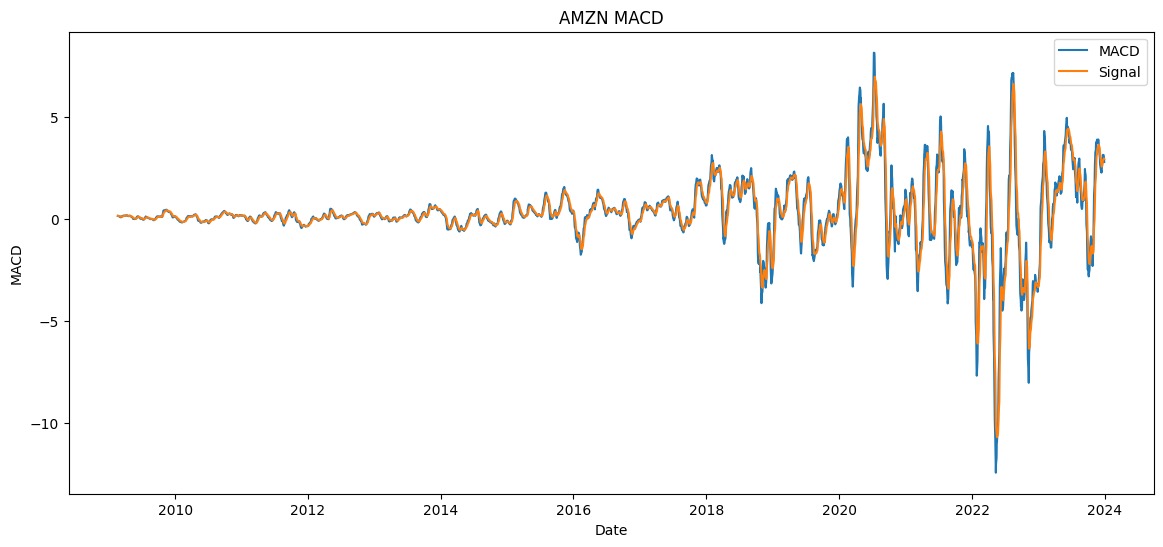

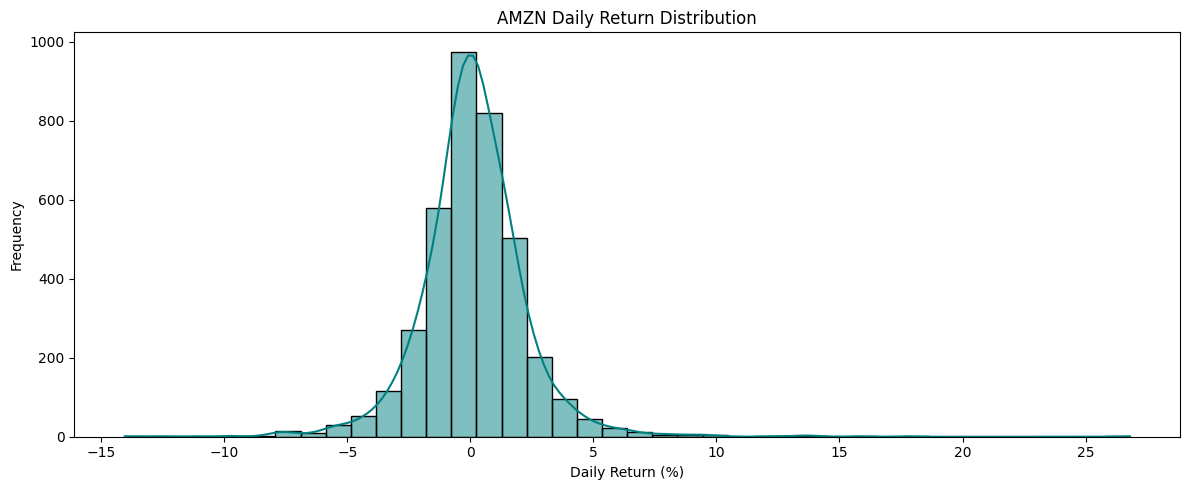

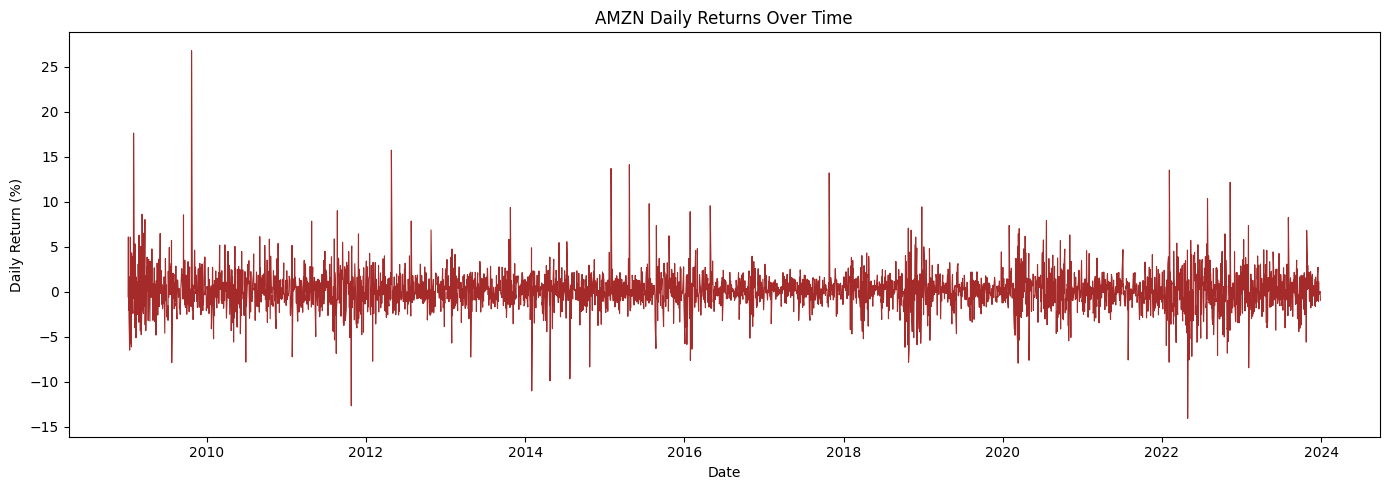

In [39]:
# Analyze AMZN explicitly
symbol = 'AMZN'
print(f"--- Analyzing {symbol} ---")
analyze_stock(stock_data[symbol], symbol)


--- Analyzing GOOG ---


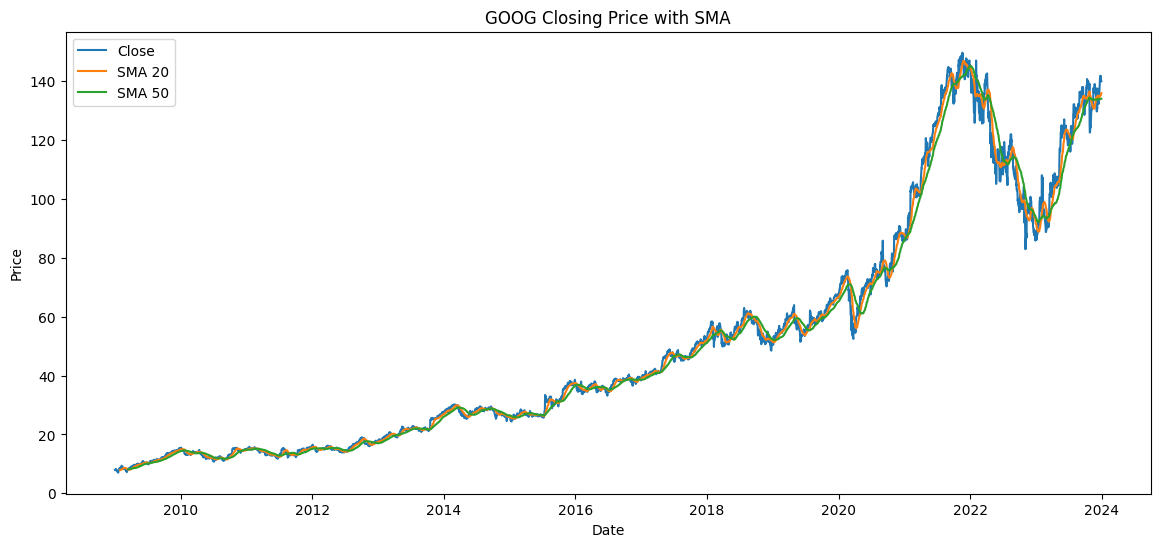

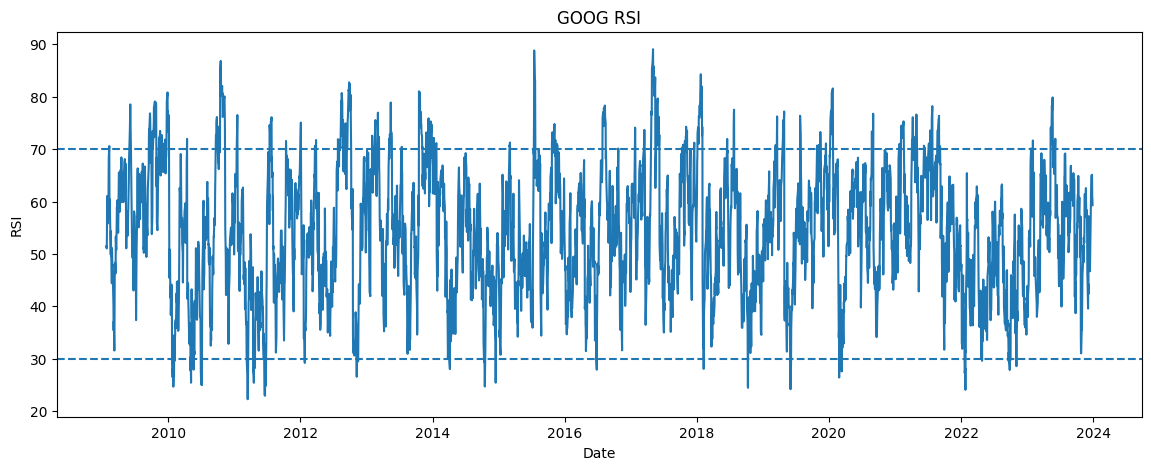

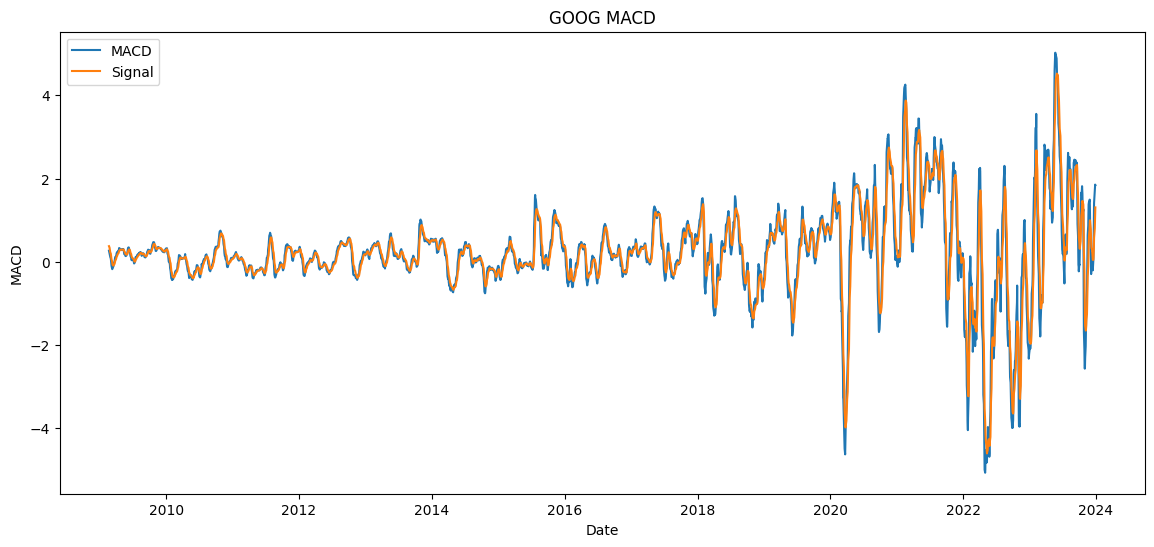

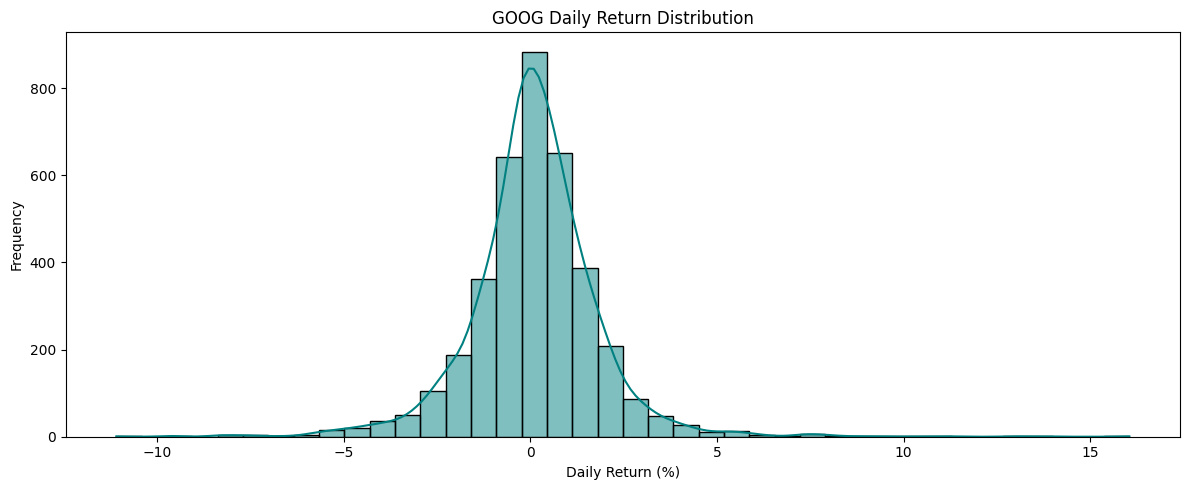

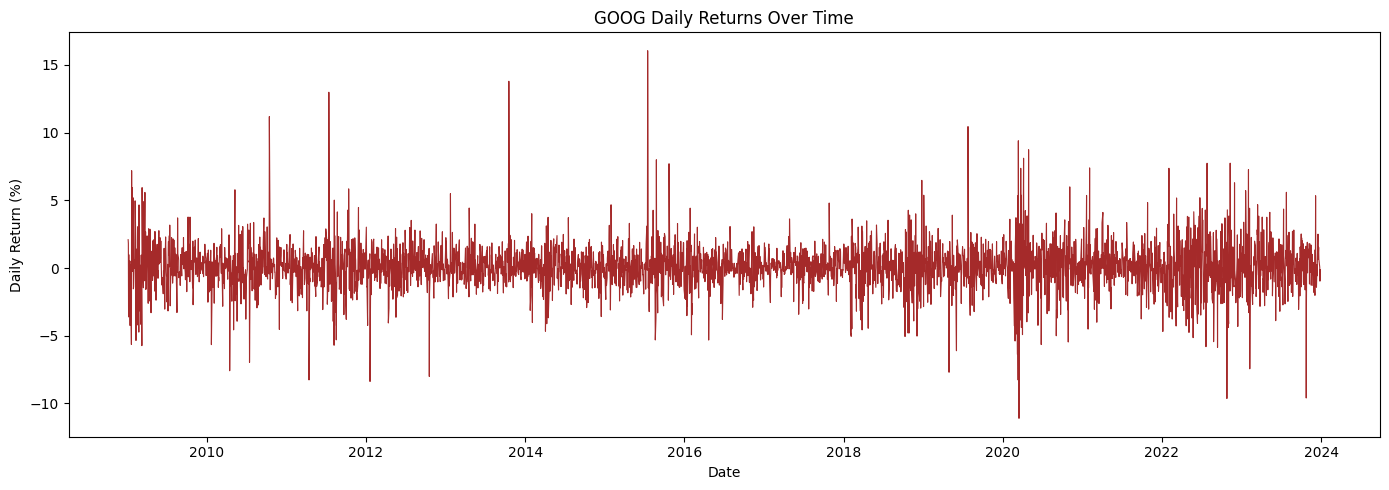

In [40]:
# Analyze GOOG explicitly
symbol = 'GOOG'
print(f"--- Analyzing {symbol} ---")
analyze_stock(stock_data[symbol], symbol)


--- Analyzing META ---


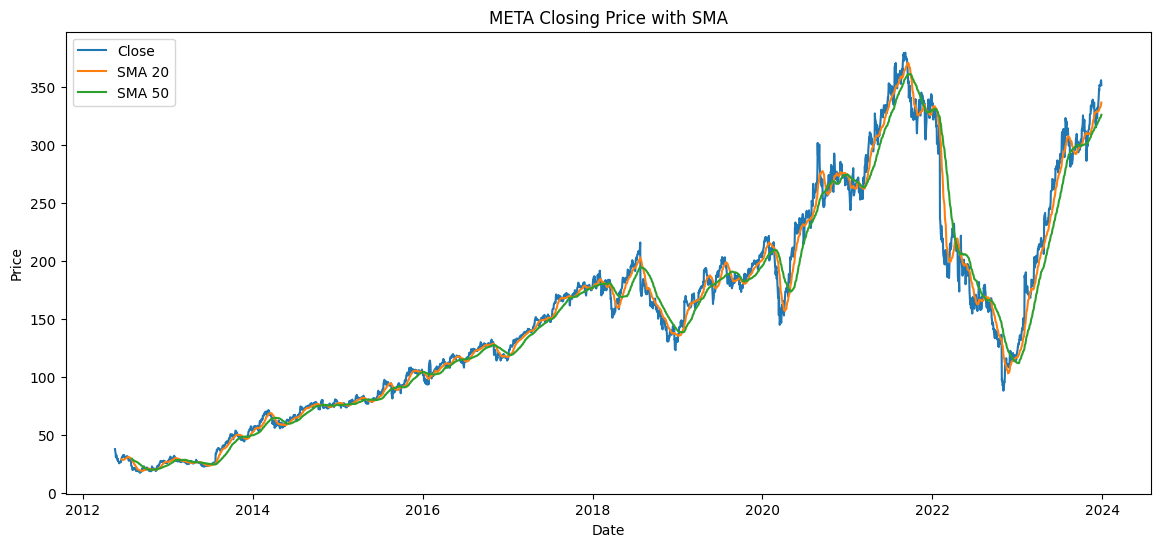

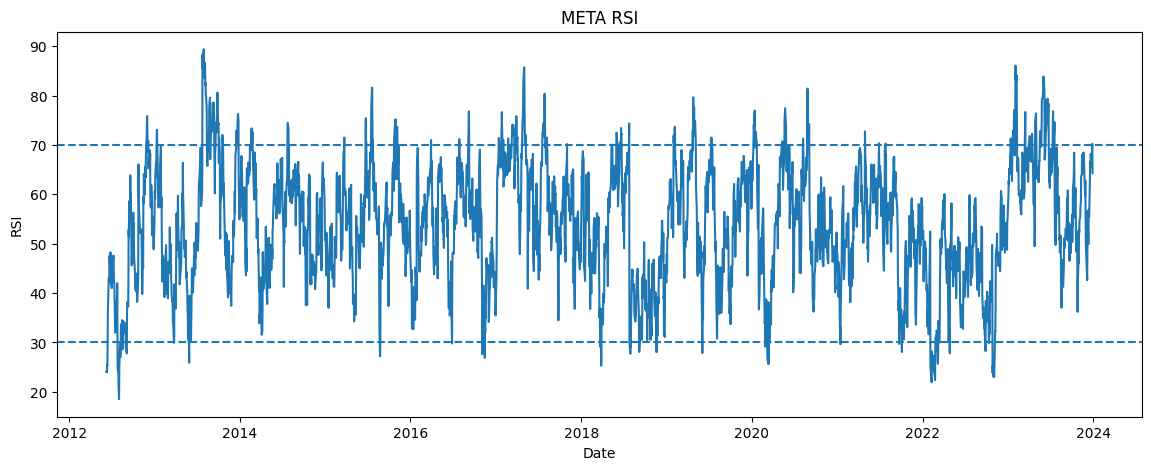

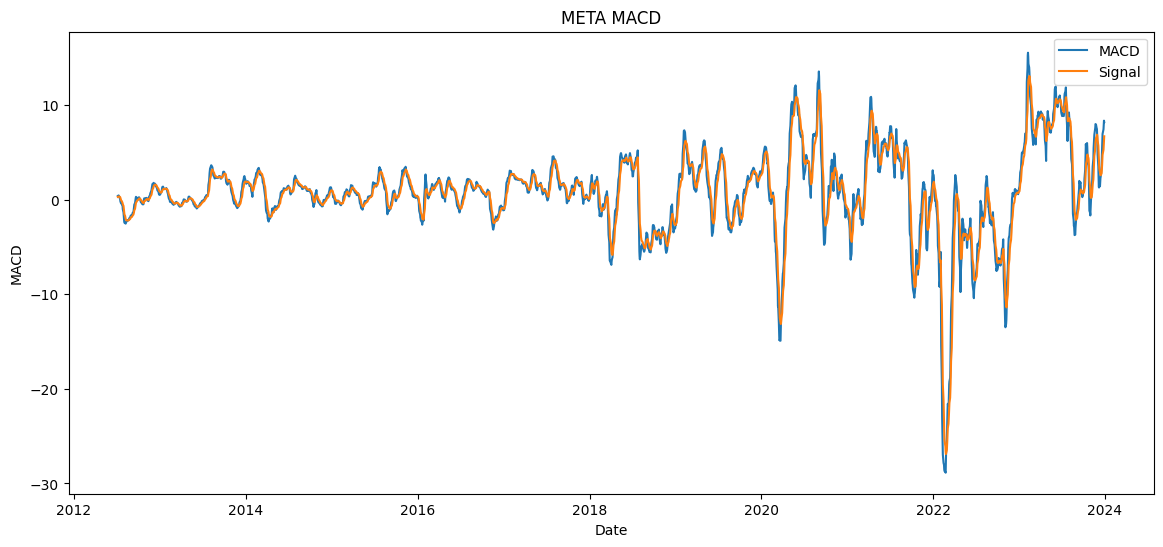

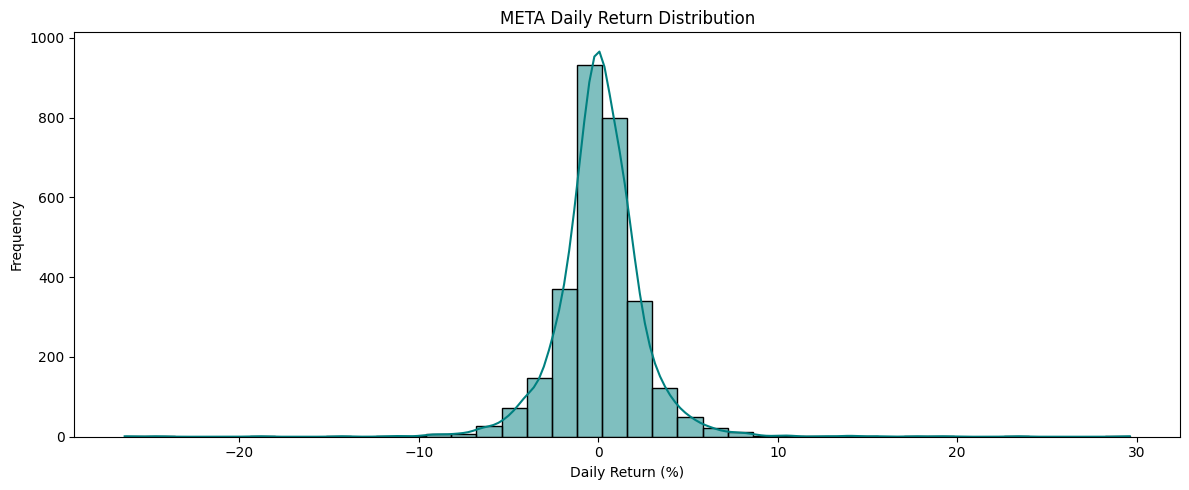

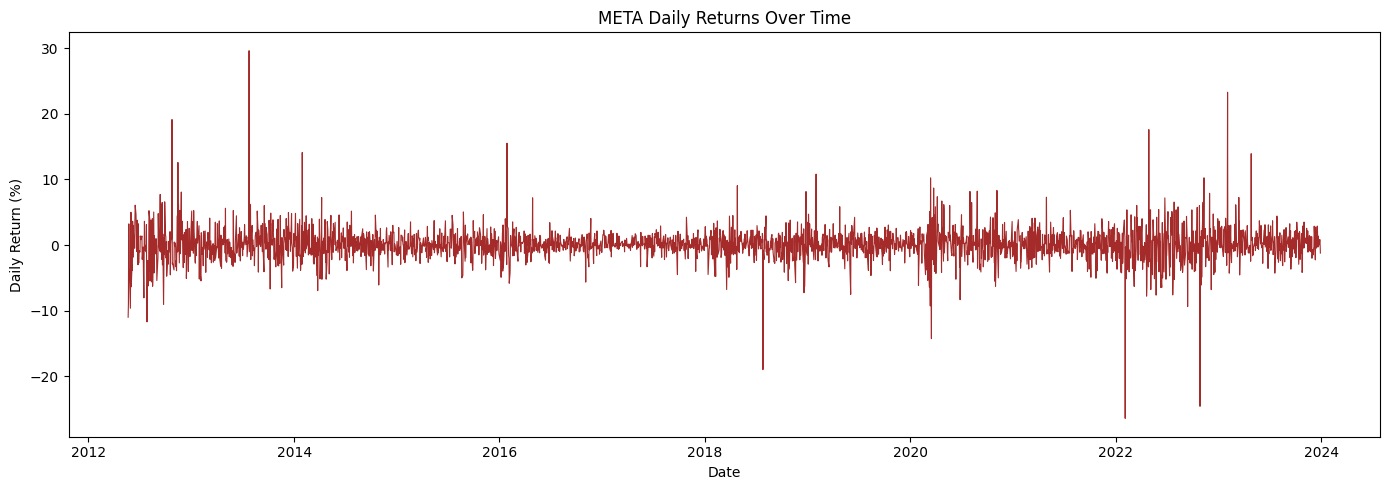

In [41]:
# Analyze META explicitly
symbol = 'META'
print(f"--- Analyzing {symbol} ---")
analyze_stock(stock_data[symbol], symbol)


--- Analyzing NVDA ---


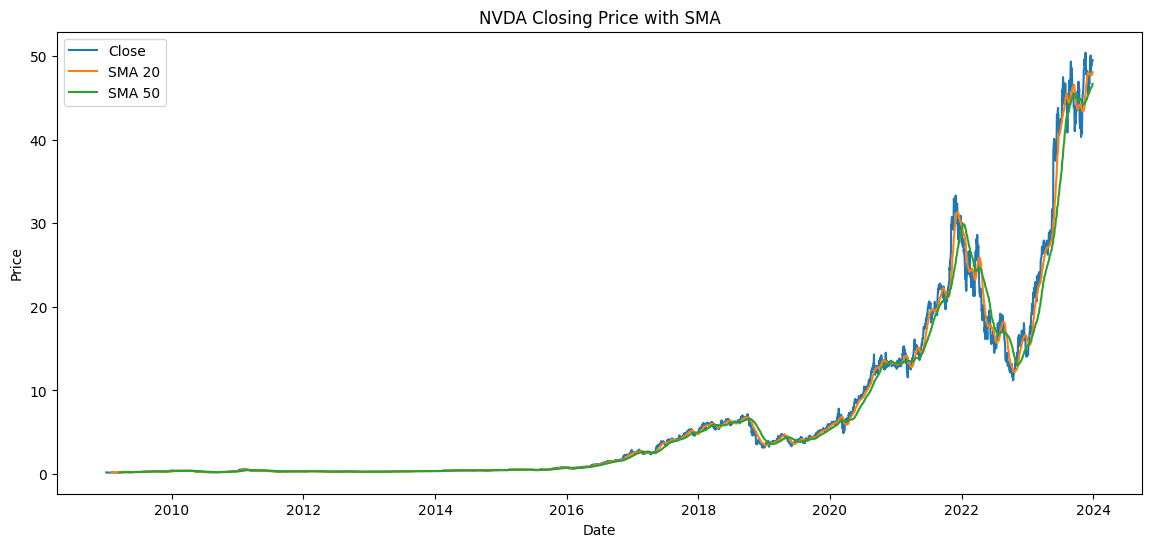

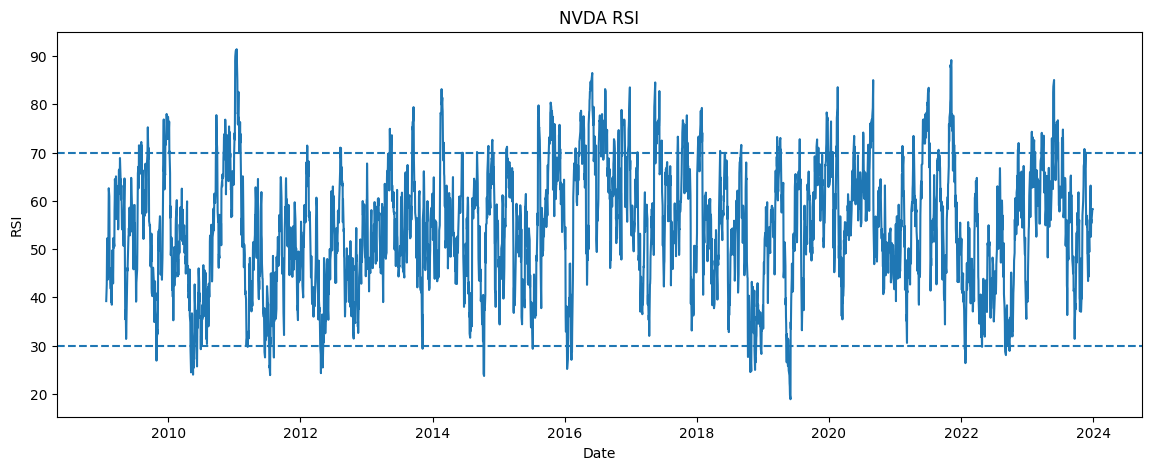

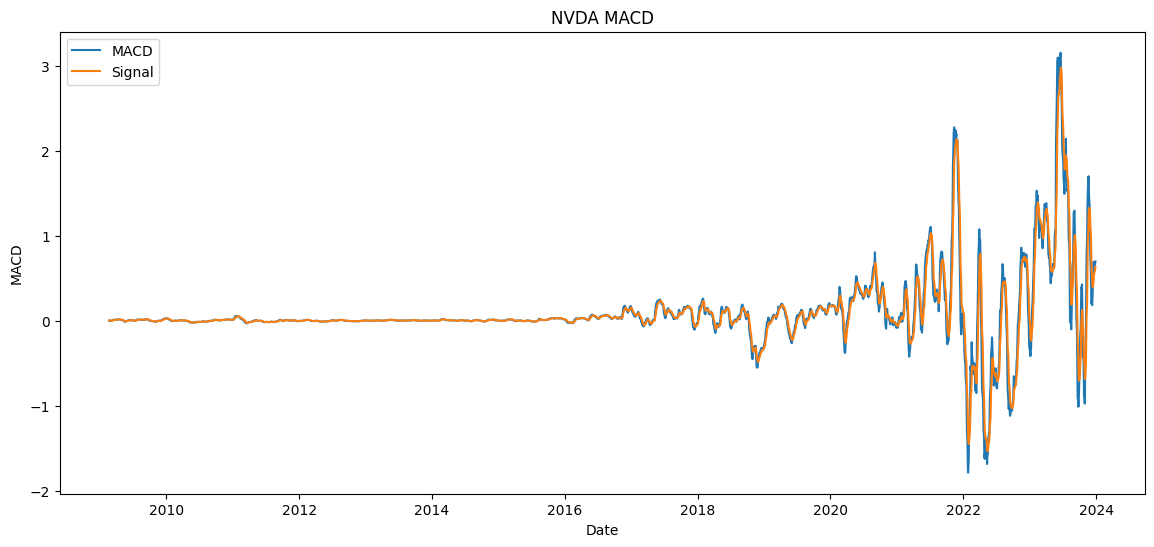

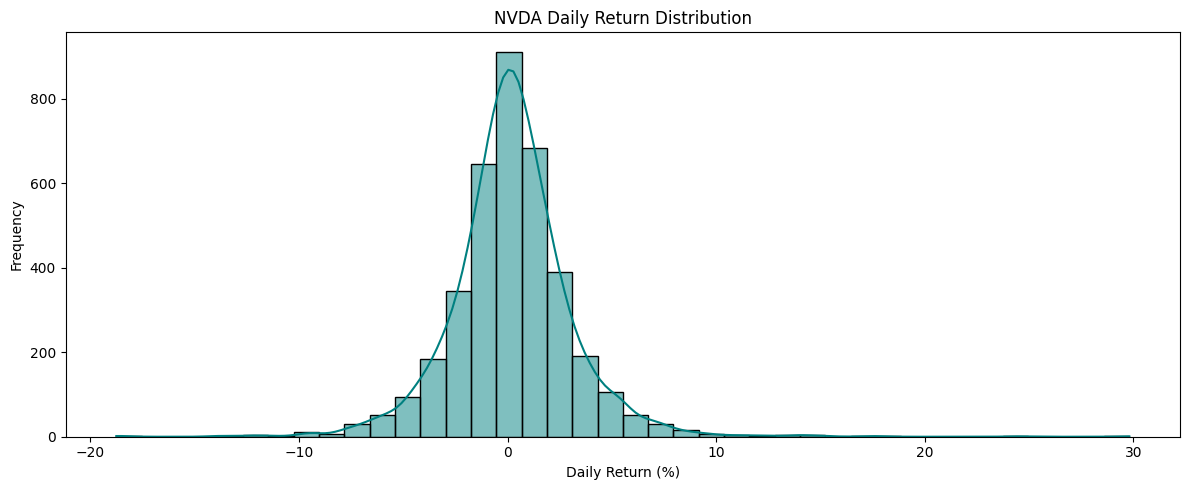

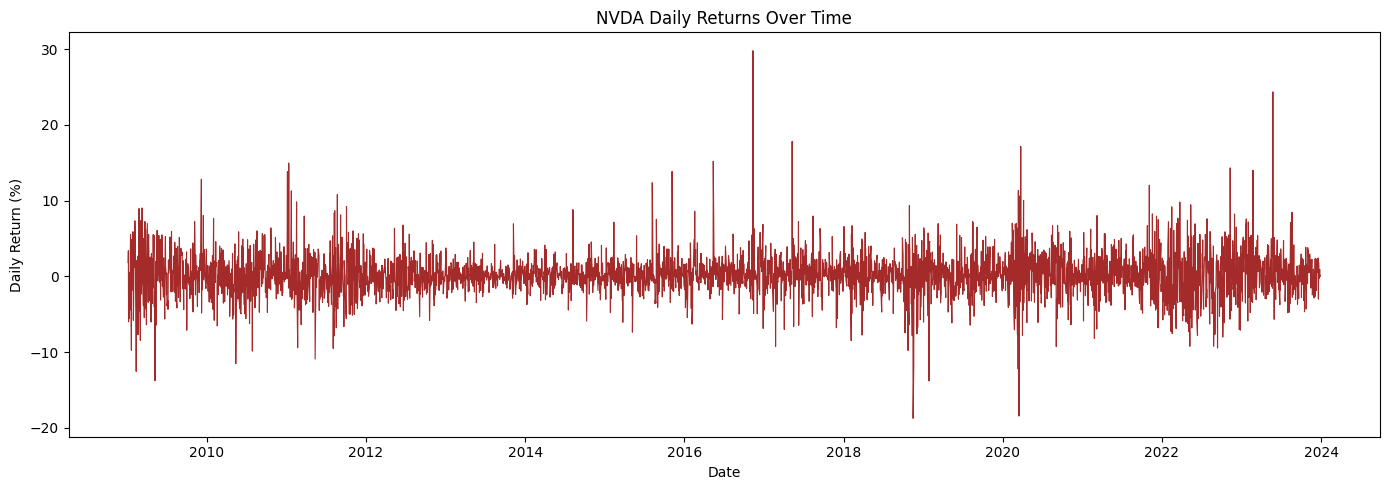

In [42]:
# Analyze AMZN explicitly
symbol = 'NVDA'
print(f"--- Analyzing {symbol} ---")
analyze_stock(stock_data[symbol], symbol)
    